# Step 6 - Model Evaluation (V2)

## Purpose

This notebook replaces the label handling in the original Step 6 evaluation. The CNN in Step 5 was trained with **folder-derived target labels**, because the dataset's `Disease_Type` metadata disagrees systematically with the Healthy and Leaf Blight folders. This evaluation therefore derives `Target_Class` from each resolved image's parent folder and uses that same definition for the test labels.

The original metadata label is retained only for traceability and comparison. It is **not** used as the ground truth for the V2 metrics. The filename is used to locate the file, but only decoded RGB pixels are passed to the CNN.

## Where to run this notebook

Run this notebook in the environment that contains all three required inputs:

1. this Git repository;
2. the complete GVLiD image folders; and
3. `cnn_final.keras` produced by Step 5.

Google Colab is recommended if the model and dataset are already stored in Google Drive. Mount Drive, clone or open the latest repository, and edit only the two optional path overrides in the configuration cell below. Evaluation does not require model retraining and can also run locally if TensorFlow, the images and the saved model are available.

In [14]:
from collections import defaultdict
from pathlib import Path
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

## Configuration

The automatic project-root discovery works when the notebook is run from the repository root or its `notebooks` directory. In Colab, set `RAW_DATA_OVERRIDE` and `MODEL_PATH_OVERRIDE` if the large files are stored in Google Drive.

In [16]:
# Optional Colab setup (uncomment if needed):
# from google.colab import drive
# drive.mount('/content/drive')

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'processed' / 'dataset_split.csv').exists():
            return candidate
    raise FileNotFoundError(
        'Could not find the project root containing data/processed/dataset_split.csv.'
    )

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src import RANDOM_SEED

# Set either value to a Path if Colab/Drive stores the files elsewhere.
RAW_DATA_OVERRIDE = None
MODEL_PATH_OVERRIDE = None
# Example:
# RAW_DATA_OVERRIDE = Path('/content/drive/MyDrive/grapevine/GVLiD')
# MODEL_PATH_OVERRIDE = Path('/content/drive/MyDrive/grapevine/cnn_final.keras')

default_raw_root = PROJECT_ROOT / 'data' / 'raw' / 'GVLiD'
if not default_raw_root.exists():
    default_raw_root = PROJECT_ROOT / 'data' / 'raw'

RAW_DATA_DIR = Path(RAW_DATA_OVERRIDE) if RAW_DATA_OVERRIDE else default_raw_root
MODEL_PATH = (
    Path(MODEL_PATH_OVERRIDE)
    if MODEL_PATH_OVERRIDE
    else PROJECT_ROOT / 'results' / 'cnn_v2_final.keras'
)
SPLIT_FILE = PROJECT_ROOT / 'data' / 'processed' / 'dataset_split.csv'
HISTORY_PATH = PROJECT_ROOT / 'results' / 'training_history.pkl'
OUTPUT_DIR = PROJECT_ROOT / 'results' / 'evaluation_v2'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['Black Rot', 'Esca', 'Healthy', 'Leaf Blight']
LABEL_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}

CLASS_TO_FOLDER = {
    "Black Rot": "Black rot",
    "Esca": "esca",
    "Healthy": "healthy",
    "Leaf Blight": "leaf blight",
}
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print('Project root:', PROJECT_ROOT)
print('Raw data:', RAW_DATA_DIR)
print('Model:', MODEL_PATH)
print('Split file:', SPLIT_FILE)

Project root: /home/chetan/Desktop/DL_Project/grapevine-disease-classification
Raw data: /home/chetan/Desktop/DL_Project/grapevine-disease-classification/data/raw/GVLiD
Model: /home/chetan/Desktop/DL_Project/grapevine-disease-classification/results/cnn_v2_final.keras
Split file: /home/chetan/Desktop/DL_Project/grapevine-disease-classification/data/processed/dataset_split.csv


In [17]:
required_paths = {
    'raw image directory': RAW_DATA_DIR,
    'trained model': MODEL_PATH,
    'split manifest': SPLIT_FILE,
}
missing_inputs = {name: path for name, path in required_paths.items() if not path.exists()}
if missing_inputs:
    details = '\n'.join(f'- {name}: {path}' for name, path in missing_inputs.items())
    raise FileNotFoundError(
        'Required evaluation inputs are missing. Correct the configuration paths before continuing:\n'
        + details
    )

print('All required inputs are available.')

All required inputs are available.


## Resolve images and reconstruct the modelling target

This is the key V2 correction. Image files are located recursively, and `Target_Class` is derived from the resolved image's class folder. `Disease_Type` remains in the table only so the disagreement can be audited.

In [18]:
required_columns = {"image_filename", "Vineyard", "Split", "Target_Class"}

missing_columns = required_columns - set(split_df.columns)

if missing_columns:
    raise ValueError(f"Split manifest is missing columns: {sorted(missing_columns)}")

split_df["image_path"] = split_df.apply(
    lambda row: str(
        RAW_DATA_DIR / CLASS_TO_FOLDER[row["Target_Class"]] / row["image_filename"]
    ),
    axis=1,
)

split_df["label"] = split_df["Target_Class"].map(LABEL_TO_INDEX).astype(np.int32)

# Verify that all image paths exist
missing_images = split_df[~split_df["image_path"].map(Path).map(Path.exists)]

if not missing_images.empty:
    raise FileNotFoundError(
        f"{len(missing_images)} images could not be found. "
        f"Examples: {missing_images['image_filename'].head().tolist()}"
    )

print("Manifest rows:", len(split_df))
print("Resolved images:", split_df["image_path"].notna().sum())
print("Missing images:", len(missing_images))

display(pd.crosstab(split_df["Target_Class"], split_df["Split"]))

Manifest rows: 2407
Resolved images: 2407
Missing images: 0


Split,Test,Train,Validation
Target_Class,,,
Black Rot,15,68,14
Esca,133,620,133
Healthy,164,765,164
Leaf Blight,50,231,50


In [19]:
test_df = split_df[split_df['Split'].str.lower() == 'test'].copy().reset_index(drop=True)

if test_df.empty:
    raise ValueError('The split manifest contains no Test rows.')
if set(test_df['Target_Class']) != set(CLASS_NAMES):
    raise ValueError(
        'The test subset does not contain exactly the four expected target classes: '
        f'{sorted(test_df.Target_Class.unique())}'
    )

print('Test images:', len(test_df))
print('Corrected folder-derived test distribution:')
display(test_df['Target_Class'].value_counts().reindex(CLASS_NAMES).rename('support'))

Test images: 362
Corrected folder-derived test distribution:


Target_Class
Black Rot       15
Esca           133
Healthy        164
Leaf Blight     50
Name: support, dtype: int64

## Build the test pipeline

Only decoded, resized and normalised RGB pixels are passed to the CNN. Filenames, folder names and metadata are not model inputs. The test dataset is not shuffled so predictions remain aligned with `test_df`.

In [20]:
def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

paths = test_df['image_path'].astype(str).to_numpy()
labels = test_df['label'].to_numpy(dtype=np.int32)
test_ds = tf.data.Dataset.from_tensor_slices((paths, labels))
test_ds = test_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print('Test batches:', int(tf.data.experimental.cardinality(test_ds)))

Test batches: 12


## Load and validate the trained model

In [21]:
model = tf.keras.models.load_model(MODEL_PATH)
input_shape = tuple(model.input_shape[1:])
expected_input_shape = (*IMG_SIZE, 3)
if input_shape != expected_input_shape:
    raise ValueError(
        f'Model input shape is {input_shape}; expected {expected_input_shape} from Step 5.'
    )
output_units = int(model.output_shape[-1])
if output_units != len(CLASS_NAMES):
    raise ValueError(
        f'Model has {output_units} output units; expected {len(CLASS_NAMES)} for {CLASS_NAMES}.'
    )

print('Model loaded successfully.')
print('Model input shape:', input_shape)
print('Model output classes:', output_units)

Model loaded successfully.
Model input shape: (128, 128, 3)
Model output classes: 4


## Generate predictions using corrected test labels

In [22]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
y_prob = model.predict(test_ds, verbose=1)
y_true = labels
y_pred = np.argmax(y_prob, axis=1)

if len(y_pred) != len(test_df):
    raise RuntimeError('Prediction count does not match the test manifest.')
prediction_accuracy = accuracy_score(y_true, y_pred)
if not np.isclose(test_accuracy, prediction_accuracy, atol=1e-6):
    raise RuntimeError(
        f'model.evaluate accuracy ({test_accuracy}) does not match prediction accuracy '
        f'({prediction_accuracy}). Check test ordering and preprocessing.'
    )

print(f'Corrected test loss: {test_loss:.4f}')
print(f'Corrected test accuracy: {test_accuracy:.4f}')

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 250ms/step - accuracy: 0.8481 - loss: 0.3856
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step
Corrected test loss: 0.3856
Corrected test accuracy: 0.8481


## Multiclass evaluation

Macro metrics give every class equal importance. The majority-class baseline is included so the CNN is not judged by accuracy in isolation.

In [23]:
accuracy = accuracy_score(y_true, y_pred)
macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
majority_baseline = test_df['Target_Class'].value_counts(normalize=True).max()

summary_df = pd.DataFrame({
    'Metric': [
        'Test loss', 'Test accuracy', 'Macro precision', 'Macro recall',
        'Macro F1', 'Weighted F1', 'Majority-class accuracy baseline'
    ],
    'Score': [
        test_loss, accuracy, macro_precision, macro_recall,
        macro_f1, weighted_f1, majority_baseline
    ],
})
display(summary_df.round(4))

report_dict = classification_report(
    y_true,
    y_pred,
    labels=range(len(CLASS_NAMES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.round(4))

,Metric,Score
0,Test loss,0.3856
1,Test accuracy,0.8481
2,Macro precision,0.7653
3,Macro recall,0.6624
4,Macro F1,0.6928
5,Weighted F1,0.8373
6,Majority-class accuracy baseline,0.4530


,precision,recall,f1-score,support
Black Rot,0.7143,0.3333,0.4545,15.0000
Esca,0.7881,0.8947,0.8380,133.0000
Healthy,0.9641,0.9817,0.9728,164.0000
Leaf Blight,0.5946,0.4400,0.5057,50.0000
accuracy,0.8481,0.8481,0.8481,0.8481
macro avg,0.7653,0.6624,0.6928,362.0000
weighted avg,0.8380,0.8481,0.8373,362.0000


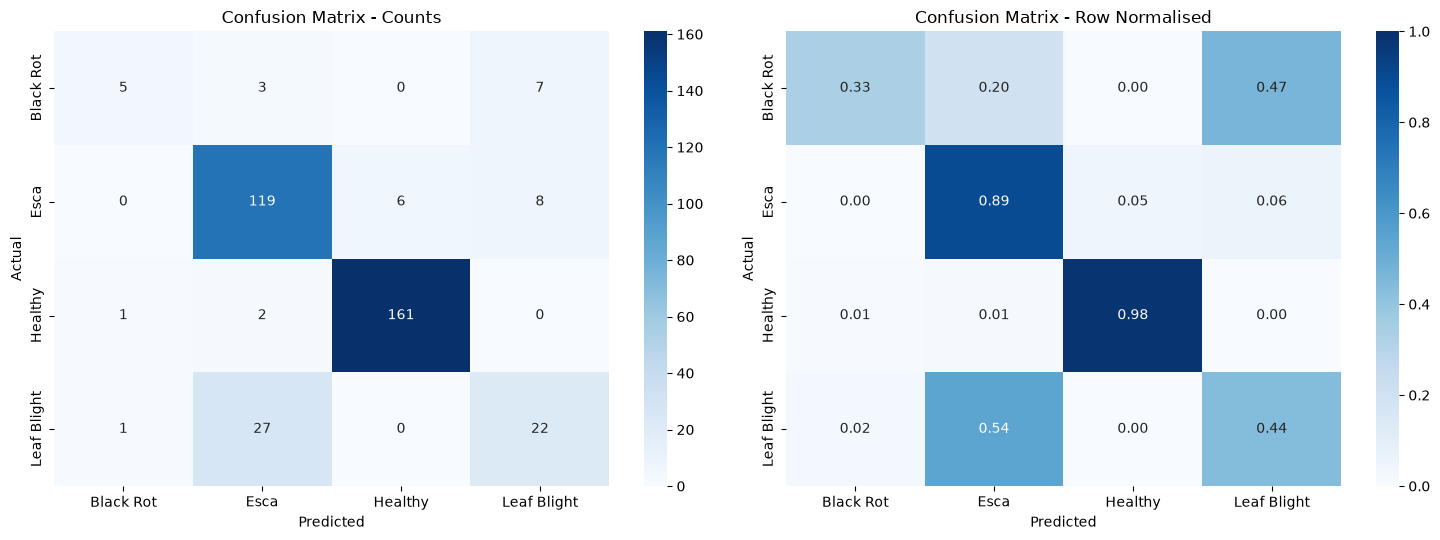

In [24]:
cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASS_NAMES)))
cm_normalized = confusion_matrix(
    y_true, y_pred, labels=range(len(CLASS_NAMES)), normalize='true'
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0]
)
axes[0].set(title='Confusion Matrix - Counts', xlabel='Predicted', ylabel='Actual')
sns.heatmap(
    cm_normalized, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1]
)
axes[1].set(title='Confusion Matrix - Row Normalised', xlabel='Predicted', ylabel='Actual')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices_v2.png', dpi=300, bbox_inches='tight')
plt.show()

## Decision-support view: disease triage

The four-class metrics evaluate disease classification. For the proposed inspection-prioritisation use case, it is also useful to ask whether the model separates **any disease** from Healthy. Disease recall measures how many truly diseased test images would be flagged for review. This binary view supplements rather than replaces the four-class evaluation.

,Metric,Score
0,Disease precision,0.9846
1,Disease recall,0.9697
2,Disease F1,0.9771
3,Proportion flagged for review,0.5387


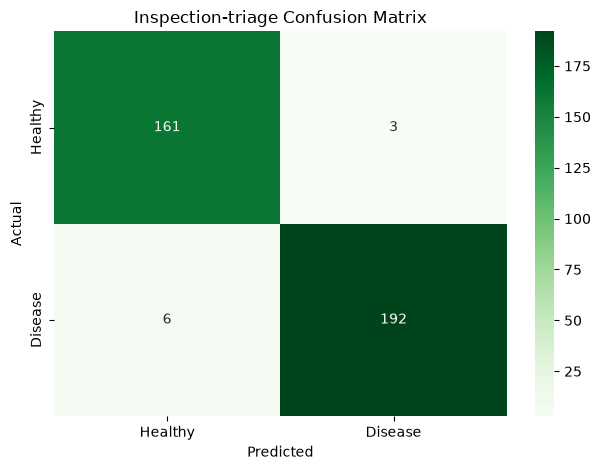

In [25]:
healthy_index = LABEL_TO_INDEX['Healthy']
y_true_disease = (y_true != healthy_index).astype(int)
y_pred_disease = (y_pred != healthy_index).astype(int)

triage_precision = precision_score(y_true_disease, y_pred_disease, zero_division=0)
triage_recall = recall_score(y_true_disease, y_pred_disease, zero_division=0)
triage_f1 = f1_score(y_true_disease, y_pred_disease, zero_division=0)
triage_cm = confusion_matrix(y_true_disease, y_pred_disease, labels=[0, 1])
review_rate = y_pred_disease.mean()

triage_df = pd.DataFrame({
    'Metric': ['Disease precision', 'Disease recall', 'Disease F1', 'Proportion flagged for review'],
    'Score': [triage_precision, triage_recall, triage_f1, review_rate],
})
display(triage_df.round(4))

sns.heatmap(
    triage_cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease']
)
plt.title('Inspection-triage Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'triage_confusion_matrix_v2.png', dpi=300, bbox_inches='tight')
plt.show()

## Error analysis

High-confidence errors are especially important because softmax confidence is not proof of correctness. Review these examples for symptom similarity, background cues, image quality and possible remaining label problems.

Incorrect predictions: 55


,Image_ID,image_filename,Vineyard,Disease_Type,Target_Class,metadata_agrees_with_target,image_path,Predicted_Class,Confidence,Correct,Probability_Black Rot,Probability_Esca,Probability_Healthy,Probability_Leaf Blight
241,leaf blight531.jpg,leaf blight531.jpg,Vineyard_24,<NA>,Leaf Blight,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Esca,0.922801,False,0.000025,0.922801,0.003886,0.073288
295,healthy570.jpg,healthy570.jpg,Vineyard_12,<NA>,Healthy,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Esca,0.922691,False,0.000049,0.922691,0.009917,0.067343
324,leaf blight329.jpg,leaf blight329.jpg,Vineyard_19,<NA>,Leaf Blight,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Esca,0.918380,False,0.000027,0.918380,0.043180,0.038413
192,leaf blight481.jpg,leaf blight481.jpg,Vineyard_6,<NA>,Leaf Blight,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Esca,0.881431,False,0.000018,0.881431,0.000029,0.118522
291,leaf blight389.jpg,leaf blight389.jpg,Vineyard_11,<NA>,Leaf Blight,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Esca,0.875720,False,0.000593,0.875720,0.016532,0.107155
29,healthy643.jpg,healthy643.jpg,Vineyard_21,<NA>,Healthy,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Esca,0.841565,False,0.000007,0.841565,0.138653,0.019776
37,esca491.jpg,esca491.jpg,Vineyard_23,<NA>,Esca,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Healthy,0.834307,False,0.000008,0.162476,0.834307,0.003209
201,leaf blight375.jpg,leaf blight375.jpg,Vineyard_5,<NA>,Leaf Blight,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Esca,0.812385,False,0.000009,0.812385,0.000002,0.187604
242,esca781.jpg,esca781.jpg,Vineyard_21,<NA>,Esca,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Healthy,0.795019,False,0.000803,0.189476,0.795019,0.014701
111,leaf blight415.jpg,leaf blight415.jpg,Vineyard_3,<NA>,Leaf Blight,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Esca,0.785423,False,0.000073,0.785423,0.000018,0.214486


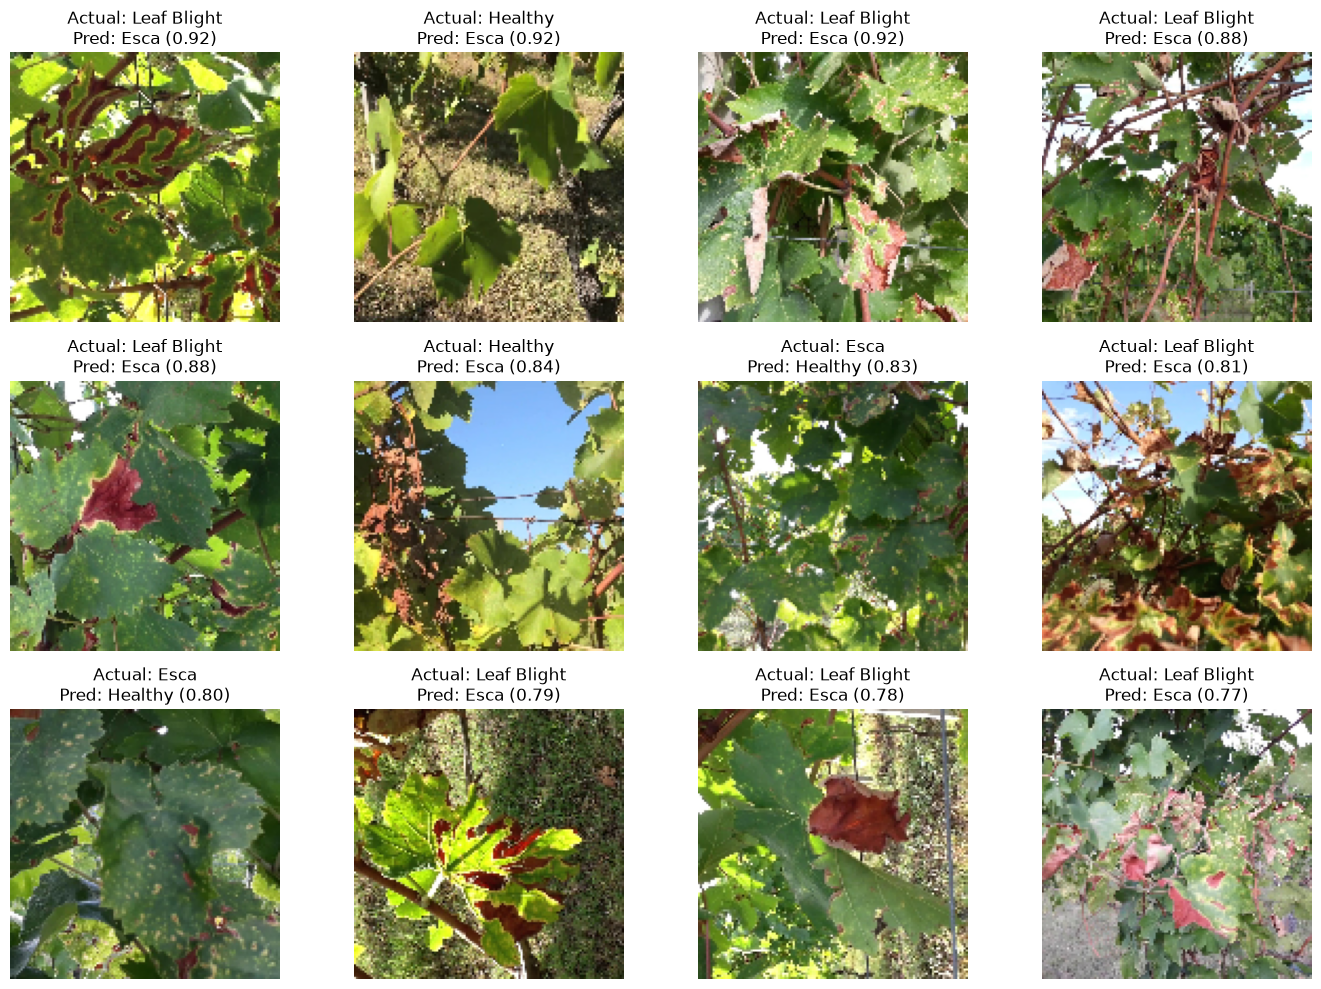

In [27]:
prediction_columns = [
    'Image_ID',
    'image_filename',
    'Vineyard',
    'Disease_Type',
    'Target_Class',
    'metadata_agrees_with_target',
    'image_path',
]

predictions_df = test_df.copy()

# Use available manifest columns and provide traceability fallbacks.
if 'Image_ID' not in predictions_df:
    predictions_df['Image_ID'] = predictions_df['image_filename']

for column in ['Disease_Type', 'metadata_agrees_with_target']:
    if column not in predictions_df:
        predictions_df[column] = pd.NA

predictions_df = predictions_df[prediction_columns].copy()
predictions_df['Predicted_Class'] = [CLASS_NAMES[i] for i in y_pred]
predictions_df['Confidence'] = y_prob.max(axis=1)
predictions_df['Correct'] = (y_true == y_pred)
for index, class_name in enumerate(CLASS_NAMES):
    predictions_df[f'Probability_{class_name}'] = y_prob[:, index]

errors_df = predictions_df[~predictions_df['Correct']].sort_values(
    'Confidence', ascending=False
)
print('Incorrect predictions:', len(errors_df))
display(errors_df.head(10))

sample_errors = errors_df.head(12)
if not sample_errors.empty:
    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    for axis in axes.flat:
        axis.axis('off')
    for axis, (_, row) in zip(axes.flat, sample_errors.iterrows()):
        image = tf.keras.utils.load_img(row['image_path'], target_size=IMG_SIZE)
        axis.imshow(image)
        axis.set_title(
            f"Actual: {row['Target_Class']}\n"
            f"Pred: {row['Predicted_Class']} ({row['Confidence']:.2f})"
        )
        axis.axis('off')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'high_confidence_errors_v2.png', dpi=300, bbox_inches='tight')
    plt.show()

## Training history (if available)

Training and validation curves describe model fitting. They must not be substituted for the corrected held-out test metrics above.

In [28]:
if HISTORY_PATH.exists():
    with open(HISTORY_PATH, 'rb') as file:
        history = pickle.load(file)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(history['accuracy'], label='Training')
    axes[0].plot(history['val_accuracy'], label='Validation')
    axes[0].set(title='Training and Validation Accuracy', xlabel='Epoch', ylabel='Accuracy')
    axes[0].legend()
    axes[1].plot(history['loss'], label='Training')
    axes[1].plot(history['val_loss'], label='Validation')
    axes[1].set(title='Training and Validation Loss', xlabel='Epoch', ylabel='Loss')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'training_history_v2.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Training history not found; skipping curves:', HISTORY_PATH)

Training history not found; skipping curves: /home/chetan/Desktop/DL_Project/grapevine-disease-classification/results/training_history.pkl


## Save corrected results

V2 outputs use separate filenames and do not overwrite the original, invalid evaluation results.

In [29]:
summary_df.to_csv(OUTPUT_DIR / 'summary_metrics_v2.csv', index=False)
report_df.to_csv(OUTPUT_DIR / 'classification_report_v2.csv')
triage_df.to_csv(OUTPUT_DIR / 'triage_metrics_v2.csv', index=False)
predictions_df.drop(columns=['image_path']).to_csv(
    OUTPUT_DIR / 'test_predictions_v2.csv', index=False
)
pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
    OUTPUT_DIR / 'confusion_matrix_counts_v2.csv'
)

print('Corrected evaluation outputs saved to:', OUTPUT_DIR)

Corrected evaluation outputs saved to: /home/chetan/Desktop/DL_Project/grapevine-disease-classification/results/evaluation_v2


## Interpretation checklist

Complete the final narrative only after running all cells and reviewing the corrected outputs:

- Compare corrected test accuracy with the majority-class baseline.
- Use macro F1 and per-class recall to judge whether performance is balanced.
- Identify the most important confusion pairs.
- Report disease-triage recall and the proportion of images that would be referred for human review.
- Inspect high-confidence errors and acknowledge that softmax scores are not calibrated certainty.
- State that the folder-derived target is a provisional label decision caused by a systematic metadata conflict.
- Do not claim automated diagnosis or treatment. The proposed role is prioritising human vineyard inspection.
- Make a transparent No-Go, continue-pilot, or limited-pilot recommendation based on the corrected evidence.

## Business Interpretations
Because the model separates diseased and healthy leaves with strong triage performance, it can support vineyard scouting by flagging likely unhealthy vines for human review before disease-specific treatment decisions. The practical value is time savings and earlier intervention rather than autonomous diagnosis. This is a useful decision-support tool, but it should not replace agronomic judgement.

## Limitations
The main limitation is the dataset and label ambiguity: the folder-derived target was used as a provisional ground truth because metadata and folder labels conflict systematically. Class imbalance and symptom overlap also reduce performance for some disease types, especially Leaf Blight, while overfitting risk remains possible given the limited scope of the study. As a result, the model is not yet reliable for exact disease naming in production.

## Proposed Next Pilots
Next steps should focus on improving decision quality before operational use: balance the dataset, collect more diverse vineyard images, and test augmentation plus transfer learning to improve minority-class recall. A practical pilot would add confidence thresholds and a human-review workflow so only borderline cases require agronomist input. If triage performance remains stable across new farms, the model can move from research pilot to a monitored decision-support tool.

## Final Conclusions
The corrected evaluation shows that the model is viable for vineyard triage but not yet for final disease diagnosis. It strongly separates Healthy from Disease and can therefore prioritise human inspection efficiently, while exact disease classification remains limited and uneven. The project should proceed only as a limited pilot with expert review and further data collection before any field deployment.